# TurboQuant Multi-Dataset Benchmark

Evaluate TurboQuant vs FAISS across **four embedding datasets**:

| Dataset | Dim | Vectors | Source |
|---------|-----|---------|--------|
| Clustered Synthetic | 128 | 1,000,000 | Gaussian clusters (not real SIFT) |
| GloVe-100 | 100 | ~400K | Word embeddings (Stanford NLP) |
| Sentence Embeddings | 384 | ~17K | `all-MiniLM-L6-v2` on 20 Newsgroups |
| MNIST   | 784 | 70,000 | Flattened digit images |

**Fairness notes:**
- FAISS baselines include **OPQ** (learned rotation + PQ) — the most direct competitor to TurboQuant's random rotation
- IVF indices use **nprobe = nlist** (full scan) for fair recall comparison
- All methods use **inner-product** metric on L2-normalized vectors
- Timing comparisons mix PyTorch (TQ) vs C++/SIMD (FAISS) — focus on **recall vs memory**, not speed

In [1]:
import numpy as np
import torch
import time
import os
import struct
import urllib.request
import tarfile
import gzip
import faiss

from tqtorch.search.index import TurboQuantIndex

SEED = 42
K = 10
DATA_DIR = os.path.join(os.getcwd(), 'data')
os.makedirs(DATA_DIR, exist_ok=True)

print(f"torch  {torch.__version__}")
print(f"faiss  {faiss.__version__}")
print(f"Data dir: {DATA_DIR}")

torch  2.11.0+cpu
faiss  1.13.2
Data dir: c:\Users\v-kkatla\Downloads\my-work\turboquant\tqtorch\benchmarks\data


In [7]:
# ── Shared helpers ─────────────────────────────────────────────────────────

def recall_at_k(gt, pred, k):
    """Fraction of queries whose true top-1 appears in predicted top-k."""
    return np.mean([gt[i, 0] in pred[i, :k] for i in range(gt.shape[0])])

def faiss_memory_mb(index):
    w = faiss.VectorIOWriter()
    faiss.write_index(index, w)
    return len(faiss.vector_to_array(w.data)) / 1e6

def pick_m_values(dim, count=3):
    """Pick m values that divide dim, preferring common PQ subspace counts."""
    candidates = [4, 5, 8, 10, 16, 20, 24, 25, 32, 48, 50, 64, 96]
    valid = [m for m in candidates if dim % m == 0 and m <= dim // 2]
    return valid[:count]

def run_benchmark(db, queries, gt_ids, dataset_name, dim, n_queries):
    """Run TQ + FAISS benchmarks and return results list."""
    db_t = torch.from_numpy(db.astype(np.float32))
    q_t  = torch.from_numpy(queries.astype(np.float32))
    raw_mb = db.astype(np.float32).nbytes / 1e6
    N_DB = db.shape[0]
    
    results = []
    results.append(('Raw float32', raw_mb, 1.0, 1.0, '1.0x'))
    
    # ── TurboQuant IP ─────────────────────────────────────────────────────
    for bits in [2, 3, 4, 5]:
        idx = TurboQuantIndex(dim=dim, bits=bits, metric='ip', seed=SEED)
        idx.add(db_t)
        _, ids = idx.search(q_t, k=K)
        mem = idx.memory_usage_mb
        r1  = recall_at_k(gt_ids, ids.numpy(), 1)
        r10 = recall_at_k(gt_ids, ids.numpy(), K)
        results.append((f'TQ-IP-{bits}b', mem, r1, r10, f'{raw_mb/mem:.1f}x'))
    
    # ── TurboQuant MSE ────────────────────────────────────────────────────
    for bits in [2, 3, 4, 5]:
        idx = TurboQuantIndex(dim=dim, bits=bits, metric='mse', seed=SEED)
        idx.add(db_t)
        _, ids = idx.search(q_t, k=K)
        mem = idx.memory_usage_mb
        r1  = recall_at_k(gt_ids, ids.numpy(), 1)
        r10 = recall_at_k(gt_ids, ids.numpy(), K)
        results.append((f'TQ-MSE-{bits}b', mem, r1, r10, f'{raw_mb/mem:.1f}x'))
    
    # ── FAISS SQ ──────────────────────────────────────────────────────────
    for sq_type, label in [
        (faiss.ScalarQuantizer.QT_4bit, 'FAISS-SQ-4b'),
        (faiss.ScalarQuantizer.QT_8bit, 'FAISS-SQ-8b'),
    ]:
        index = faiss.IndexScalarQuantizer(dim, sq_type, faiss.METRIC_INNER_PRODUCT)
        index.train(db.astype(np.float32)); index.add(db.astype(np.float32))
        _, ids = index.search(queries.astype(np.float32), K)
        mem = faiss_memory_mb(index)
        r1  = recall_at_k(gt_ids, ids, 1)
        r10 = recall_at_k(gt_ids, ids, K)
        results.append((label, mem, r1, r10, f'{raw_mb/mem:.1f}x'))
    
    # ── FAISS PQ ──────────────────────────────────────────────────────────
    pq_ms = pick_m_values(dim, 3)
    for m in pq_ms:
        index = faiss.IndexPQ(dim, m, 8, faiss.METRIC_INNER_PRODUCT)
        index.train(db.astype(np.float32)); index.add(db.astype(np.float32))
        _, ids = index.search(queries.astype(np.float32), K)
        mem = faiss_memory_mb(index)
        r1  = recall_at_k(gt_ids, ids, 1)
        r10 = recall_at_k(gt_ids, ids, K)
        results.append((f'FAISS-PQ(m={m})', mem, r1, r10, f'{raw_mb/mem:.1f}x'))
    
    # ── FAISS OPQ (learned rotation + PQ) ─────────────────────────────────
    opq_ms = pick_m_values(dim, 2)
    for m in opq_ms:
        opq = faiss.OPQMatrix(dim, m)
        pq_index = faiss.IndexPQ(dim, m, 8, faiss.METRIC_INNER_PRODUCT)
        index = faiss.IndexPreTransform(opq, pq_index)
        index.train(db.astype(np.float32)); index.add(db.astype(np.float32))
        _, ids = index.search(queries.astype(np.float32), K)
        mem = faiss_memory_mb(index)
        r1  = recall_at_k(gt_ids, ids, 1)
        r10 = recall_at_k(gt_ids, ids, K)
        results.append((f'FAISS-OPQ(m={m})', mem, r1, r10, f'{raw_mb/mem:.1f}x'))
    
    # ── FAISS IVF+PQ (nprobe=nlist for fair recall) ───────────────────────
    nlist = max(4, int(np.sqrt(N_DB)))
    ivf_ms = pick_m_values(dim, 2)
    for m in ivf_ms:
        quantizer = faiss.IndexFlatIP(dim)
        index = faiss.IndexIVFPQ(quantizer, dim, nlist, m, 8, faiss.METRIC_INNER_PRODUCT)
        index.train(db.astype(np.float32)); index.add(db.astype(np.float32))
        index.nprobe = nlist  # full scan for fair recall comparison
        _, ids = index.search(queries.astype(np.float32), K)
        mem = faiss_memory_mb(index)
        r1  = recall_at_k(gt_ids, ids, 1)
        r10 = recall_at_k(gt_ids, ids, K)
        results.append((f'FAISS-IVF+PQ(m={m})', mem, r1, r10, f'{raw_mb/mem:.1f}x'))
    
    return results, raw_mb

def print_results(results, raw_mb, dataset_name, n_db, dim):
    print(f"\n{'='*70}")
    print(f"  {dataset_name}  —  {n_db:,} vectors, {dim}d")
    print(f"  Raw memory: {raw_mb:.2f} MB")
    print(f"{'='*70}")
    print(f"{'Method':<22} {'Memory(MB)':>10} {'Compress':>9} {'R@1':>7} {'R@10':>7}")
    print(f"{'-'*62}")
    for name, mem, r1, r10, ratio in results:
        print(f"{name:<22} {mem:>10.2f} {ratio:>9} {r1:>7.3f} {r10:>7.3f}")
    print(f"{'='*70}")

## 1 · Clustered Synthetic  (128-dim, 1M vectors)

Clustered 128-dim Gaussian vectors (256 clusters, σ=0.1).
**Not real SIFT** — synthetic data with cluster structure to test scaling behavior.

In [8]:
# ── Clustered Synthetic: 128-dim, 1M vectors ─────────────────────────────
# Synthetic clustered Gaussians (NOT real SIFT1M).
# Tests scaling to 1M vectors with realistic cluster structure.

np.random.seed(SEED)
N_SYNTH = 1_000_000
DIM_SYNTH = 128
N_CLUSTERS = 256

# Generate clustered data
centroids = np.random.randn(N_CLUSTERS, DIM_SYNTH).astype(np.float32)
labels = np.random.randint(0, N_CLUSTERS, N_SYNTH)
synth_base = centroids[labels] + 0.1 * np.random.randn(N_SYNTH, DIM_SYNTH).astype(np.float32)

# Normalize
synth_base /= (np.linalg.norm(synth_base, axis=1, keepdims=True) + 1e-10)

# Queries
N_Q_SYNTH = 500
synth_query = np.random.randn(N_Q_SYNTH, DIM_SYNTH).astype(np.float32)
synth_query /= (np.linalg.norm(synth_query, axis=1, keepdims=True) + 1e-10)

print(f"Synthetic base:  {synth_base.shape}  ({synth_base.nbytes/1e6:.0f} MB)")
print(f"Synthetic query: {synth_query.shape}")

Synthetic base:  (1000000, 128)  (512 MB)
Synthetic query: (500, 128)


In [9]:
# Ground truth (exact IP)
flat = faiss.IndexFlatIP(DIM_SYNTH)
flat.add(synth_base)
_, synth_gt = flat.search(synth_query, K)

synth_results, synth_raw = run_benchmark(
    synth_base, synth_query, synth_gt,
    'Clustered Synthetic (128d, 1M)', DIM_SYNTH, N_Q_SYNTH)
print_results(synth_results, synth_raw, 'Clustered Synthetic (128d, 1M)', N_SYNTH, DIM_SYNTH)


  Clustered Synthetic (128d, 1M)  —  1,000,000 vectors, 128d
  Raw memory: 512.00 MB
Method                 Memory(MB)  Compress     R@1    R@10
--------------------------------------------------------------
Raw float32                512.00      1.0x   1.000   1.000
TQ-IP-2b                    36.00     14.2x   0.004   0.014
TQ-IP-3b                    52.00      9.8x   0.004   0.030
TQ-IP-4b                    68.00      7.5x   0.016   0.084
TQ-IP-5b                    84.00      6.1x   0.068   0.262
TQ-MSE-2b                   34.00     15.1x   0.006   0.046
TQ-MSE-3b                   50.00     10.2x   0.042   0.152
TQ-MSE-4b                   66.00      7.8x   0.102   0.382
TQ-MSE-5b                   82.00      6.2x   0.274   0.740
FAISS-SQ-4b                 64.00      8.0x   0.068   0.258
FAISS-SQ-8b                128.00      4.0x   0.846   1.000
FAISS-PQ(m=4)                4.13    123.9x   0.000   0.000
FAISS-PQ(m=8)                8.13     63.0x   0.000   0.004
FAISS-PQ(m=

## 2 · GloVe  (100-dim, ~1.2M word vectors)

Pre-trained word embeddings from Stanford NLP.

In [10]:
# ── Download GloVe ────────────────────────────────────────────────────────
glove_file = os.path.join(DATA_DIR, 'glove.6B.100d.txt')
glove_zip  = os.path.join(DATA_DIR, 'glove.6B.zip')

if not os.path.exists(glove_file):
    import zipfile
    print("Downloading GloVe 6B (~860MB zip)...")
    urllib.request.urlretrieve(
        'https://nlp.stanford.edu/data/glove.6B.zip', glove_zip)
    print("Extracting glove.6B.100d.txt...")
    with zipfile.ZipFile(glove_zip) as zf:
        zf.extract('glove.6B.100d.txt', DATA_DIR)
    print("Done.")
else:
    print("GloVe already downloaded.")

# Parse GloVe text file
words = []
vecs = []
with open(glove_file, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.rstrip().split(' ')
        words.append(parts[0])
        vecs.append([float(x) for x in parts[1:]])

glove_vecs = np.array(vecs, dtype=np.float32)
print(f"GloVe: {len(words)} words, shape {glove_vecs.shape}")

GloVe already downloaded.
GloVe: 400000 words, shape (400000, 100)


In [11]:
# Normalize
glove_n = glove_vecs / (np.linalg.norm(glove_vecs, axis=1, keepdims=True) + 1e-10)

# Split: last 1000 as queries
np.random.seed(SEED)
perm = np.random.permutation(len(glove_n))
N_Q_GLOVE = 500
glove_db = glove_n[perm[N_Q_GLOVE:]]
glove_q  = glove_n[perm[:N_Q_GLOVE]]

flat = faiss.IndexFlatIP(100)
flat.add(glove_db)
_, glove_gt = flat.search(glove_q, K)

glove_results, glove_raw = run_benchmark(
    glove_db, glove_q, glove_gt,
    'GloVe-100d', 100, N_Q_GLOVE)
print_results(glove_results, glove_raw, 'GloVe-100d', glove_db.shape[0], 100)


  GloVe-100d  —  399,500 vectors, 100d
  Raw memory: 159.80 MB
Method                 Memory(MB)  Compress     R@1    R@10
--------------------------------------------------------------
Raw float32                159.80      1.0x   1.000   1.000
TQ-IP-2b                    11.98     13.3x   0.240   0.512
TQ-IP-3b                    16.78      9.5x   0.344   0.706
TQ-IP-4b                    21.97      7.3x   0.512   0.916
TQ-IP-5b                    26.77      6.0x   0.696   0.992
TQ-MSE-2b                   10.79     14.8x   0.384   0.778
TQ-MSE-3b                   15.98     10.0x   0.532   0.930
TQ-MSE-4b                   20.77      7.7x   0.694   0.994
TQ-MSE-5b                   25.97      6.2x   0.798   0.998
FAISS-SQ-4b                 19.98      8.0x   0.618   0.970
FAISS-SQ-8b                 39.95      4.0x   0.982   1.000
FAISS-PQ(m=4)                1.70     94.0x   0.026   0.102
FAISS-PQ(m=5)                2.10     76.1x   0.044   0.164
FAISS-PQ(m=10)               4.10

## 3 · Sentence Embeddings (384-dim, all-MiniLM-L6-v2)

20 Newsgroups corpus embedded with `all-MiniLM-L6-v2` (384-dim).
Fast enough for CPU-only inference.

In [12]:
from sentence_transformers import SentenceTransformer
from sklearn.datasets import fetch_20newsgroups

news = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
mteb_texts = [t.strip() for t in news.data if len(t.strip()) > 50]
print(f"Texts: {len(mteb_texts)}")

# Use the fast 384-dim model (CPU-friendly)
model_384 = SentenceTransformer('all-MiniLM-L6-v2')

t0 = time.perf_counter()
mteb_embs = model_384.encode(mteb_texts, show_progress_bar=True, batch_size=256,
                              normalize_embeddings=True, convert_to_numpy=True)
print(f"Embedded {mteb_embs.shape[0]} docs in {time.perf_counter()-t0:.1f}s")
print(f"Shape: {mteb_embs.shape}")

c:\Users\v-kkatla\Downloads\my-work\turboquant\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Texts: 17886


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2689.58it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 70/70 [12:13<00:00, 10.48s/it]

Embedded 17886 docs in 734.0s
Shape: (17886, 384)


In [13]:
np.random.seed(SEED)
perm = np.random.permutation(len(mteb_embs))
N_Q_MTEB = 500
mteb_db = mteb_embs[perm[N_Q_MTEB:]]
mteb_q  = mteb_embs[perm[:N_Q_MTEB]]

flat = faiss.IndexFlatIP(384)
flat.add(mteb_db)
_, mteb_gt = flat.search(mteb_q, K)

mteb_results, mteb_raw = run_benchmark(
    mteb_db, mteb_q, mteb_gt,
    'Sentence-384d', 384, N_Q_MTEB)
print_results(mteb_results, mteb_raw, 'Sentence Embeddings (384d, 17K docs)', mteb_db.shape[0], 384)


  Sentence Embeddings (384d, 17K docs)  —  17,386 vectors, 384d
  Raw memory: 26.70 MB
Method                 Memory(MB)  Compress     R@1    R@10
--------------------------------------------------------------
Raw float32                 26.70      1.0x   1.000   1.000
TQ-IP-2b                     1.74     15.4x   0.642   0.970
TQ-IP-3b                     2.57     10.4x   0.774   0.992
TQ-IP-4b                     3.41      7.8x   0.860   1.000
TQ-IP-5b                     4.24      6.3x   0.934   1.000
TQ-MSE-2b                    1.70     15.7x   0.770   0.998
TQ-MSE-3b                    2.54     10.5x   0.870   1.000
TQ-MSE-4b                    3.37      7.9x   0.912   1.000
TQ-MSE-5b                    4.21      6.3x   0.958   1.000
FAISS-SQ-4b                  3.34      8.0x   0.888   1.000
FAISS-SQ-8b                  6.68      4.0x   0.986   1.000
FAISS-PQ(m=4)                0.46     57.7x   0.076   0.318
FAISS-PQ(m=8)                0.53     50.2x   0.190   0.528
FAISS-PQ(

## 4 · MNIST Embeddings  (784-dim, 70K vectors)

Flattened 28×28 digit images. A compact but high-dimensional real dataset.

In [14]:
from torchvision import datasets, transforms

# Load MNIST train + test
mnist_train = datasets.MNIST(DATA_DIR, train=True, download=True)
mnist_test  = datasets.MNIST(DATA_DIR, train=False, download=True)

# Flatten and normalize to unit vectors
all_imgs = np.concatenate([
    mnist_train.data.numpy().reshape(-1, 784).astype(np.float32),
    mnist_test.data.numpy().reshape(-1, 784).astype(np.float32)
])
norms = np.linalg.norm(all_imgs, axis=1, keepdims=True) + 1e-10
mnist_n = all_imgs / norms

print(f"MNIST: {mnist_n.shape}")

MNIST: (70000, 784)


In [15]:
np.random.seed(SEED)
perm = np.random.permutation(len(mnist_n))
N_Q_MNIST = 500
mnist_db = mnist_n[perm[N_Q_MNIST:]]
mnist_q  = mnist_n[perm[:N_Q_MNIST]]

flat = faiss.IndexFlatIP(784)
flat.add(mnist_db)
_, mnist_gt = flat.search(mnist_q, K)

mnist_results, mnist_raw = run_benchmark(
    mnist_db, mnist_q, mnist_gt,
    'MNIST-784d', 784, N_Q_MNIST)
print_results(mnist_results, mnist_raw, 'MNIST (784d, 70K vectors)', mnist_db.shape[0], 784)


  MNIST (784d, 70K vectors)  —  69,500 vectors, 784d
  Raw memory: 217.95 MB
Method                 Memory(MB)  Compress     R@1    R@10
--------------------------------------------------------------
Raw float32                217.95      1.0x   1.000   1.000
TQ-IP-2b                    13.90     15.7x   0.422   0.938
TQ-IP-3b                    20.71     10.5x   0.522   0.962
TQ-IP-4b                    27.52      7.9x   0.696   0.990
TQ-IP-5b                    34.33      6.3x   0.788   0.998
TQ-MSE-2b                   13.76     15.8x   0.578   0.978
TQ-MSE-3b                   20.57     10.6x   0.666   0.992
TQ-MSE-4b                   27.38      8.0x   0.794   0.998
TQ-MSE-5b                   34.19      6.4x   0.862   1.000
FAISS-SQ-4b                 27.25      8.0x   0.772   1.000
FAISS-SQ-8b                 54.49      4.0x   0.984   1.000
FAISS-PQ(m=4)                1.08    201.6x   0.096   0.352
FAISS-PQ(m=8)                1.36    160.4x   0.090   0.460
FAISS-PQ(m=16)     

## 5 · Cross-Dataset Summary

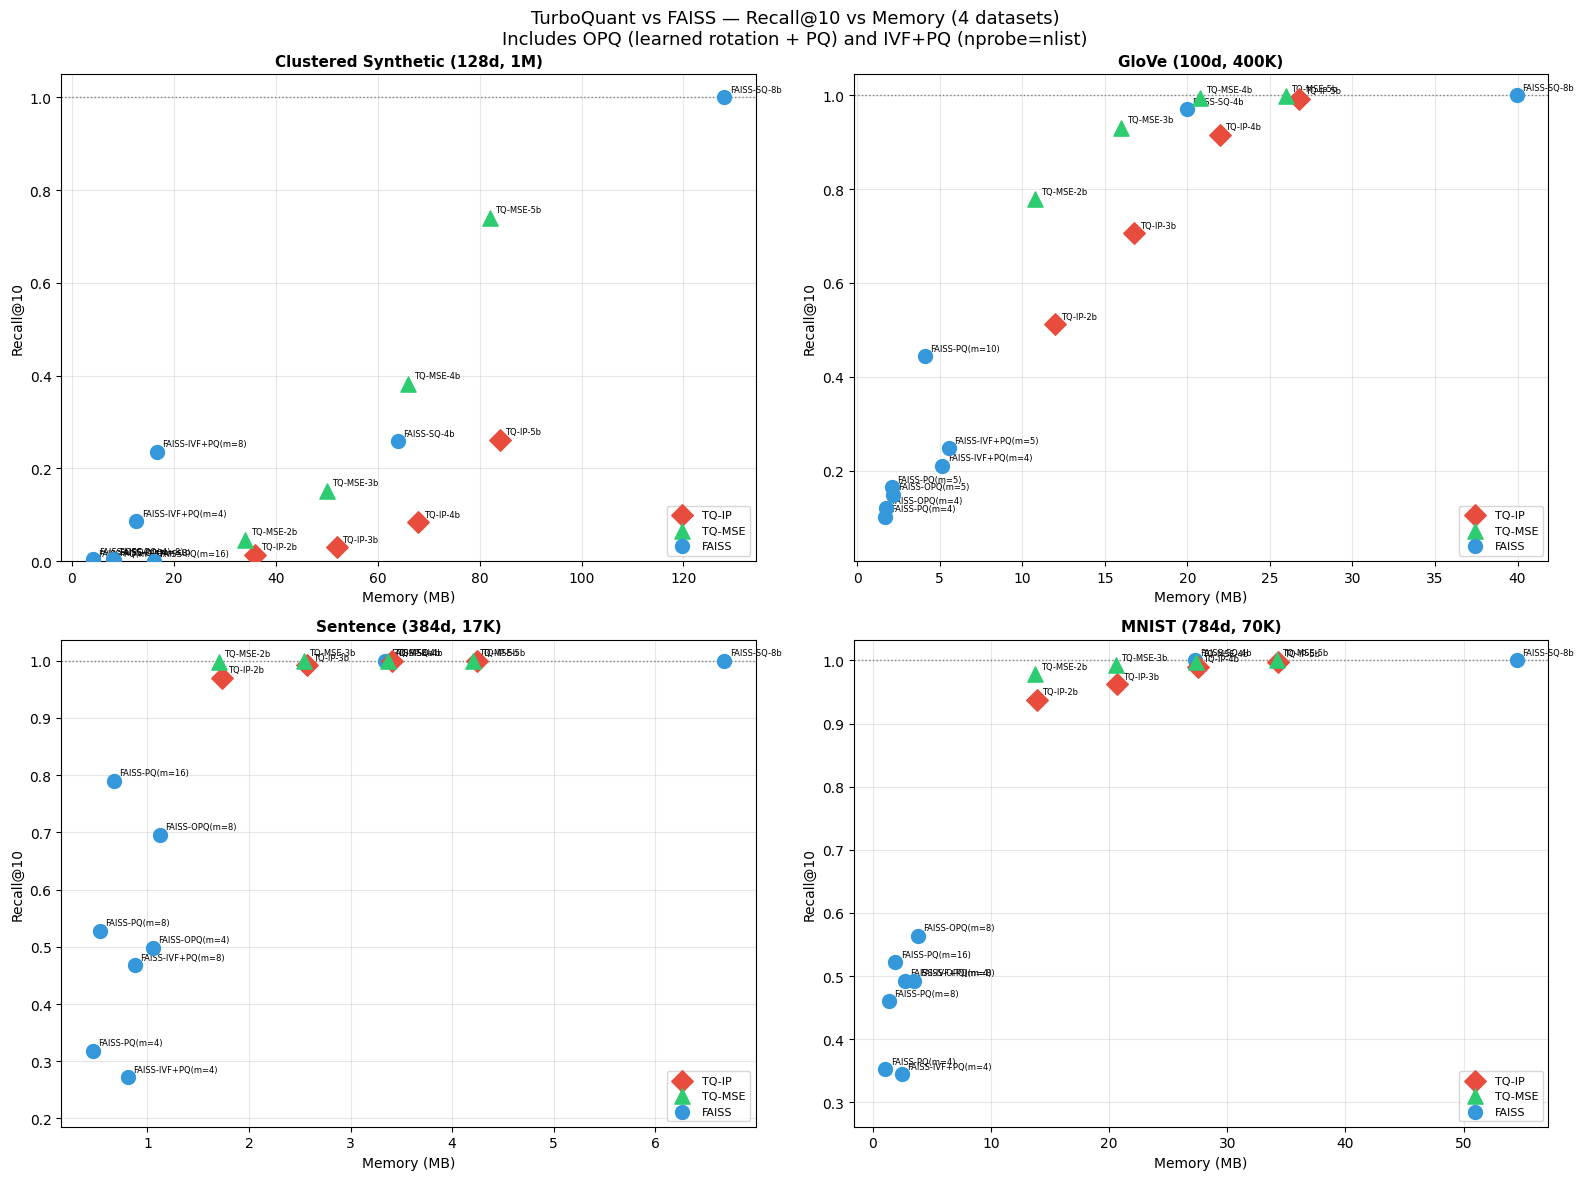

In [16]:
import matplotlib.pyplot as plt

all_datasets = [
    ('Clustered Synthetic (128d, 1M)', synth_results, synth_raw),
    ('GloVe (100d, 400K)', glove_results, glove_raw),
    ('Sentence (384d, 17K)', mteb_results, mteb_raw),
    ('MNIST (784d, 70K)', mnist_results, mnist_raw),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (title, results, raw_mb) in zip(axes.flat, all_datasets):
    tq_ip  = [r for r in results if r[0].startswith('TQ-IP')]
    tq_mse = [r for r in results if r[0].startswith('TQ-MSE')]
    faiss_r = [r for r in results if r[0].startswith('FAISS')]
    
    ax.scatter([r[1] for r in tq_ip], [r[3] for r in tq_ip],
               s=120, marker='D', color='#e74c3c', zorder=5, label='TQ-IP')
    ax.scatter([r[1] for r in tq_mse], [r[3] for r in tq_mse],
               s=120, marker='^', color='#2ecc71', zorder=5, label='TQ-MSE')
    ax.scatter([r[1] for r in faiss_r], [r[3] for r in faiss_r],
               s=100, marker='o', color='#3498db', zorder=4, label='FAISS')
    for r in results[1:]:
        ax.annotate(r[0], (r[1], r[3]), fontsize=6,
                    textcoords='offset points', xytext=(4, 4))
    ax.axhline(y=1.0, color='gray', ls=':', lw=1)
    ax.set_xlabel('Memory (MB)')
    ax.set_ylabel('Recall@10')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=max(0, ax.get_ylim()[0] - 0.05))

plt.suptitle('TurboQuant vs FAISS — Recall@10 vs Memory (4 datasets)\nIncludes OPQ (learned rotation + PQ) and IVF+PQ (nprobe=nlist)', fontsize=13)
plt.tight_layout()
plt.savefig('multi_dataset_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Final summary table ───────────────────────────────────────────────────
print(f"\n{'='*90}")
print(f"  CROSS-DATASET SUMMARY: TQ-MSE-4b vs best FAISS at similar compression")
print(f"  FAISS baselines include OPQ (learned rotation) + IVF+PQ (nprobe=nlist)")
print(f"{'='*90}")
print(f"{'Dataset':<28} {'N':>10} {'Dim':>5} │ {'TQ-MSE-4b':>10} {'FAISS-SQ-4b':>12} {'Best OPQ':>10} │ {'Compress':>8}")
print(f"{'-'*90}")

dataset_info = [
    ('Clustered Synthetic', N_SYNTH, DIM_SYNTH, synth_results, synth_raw),
    ('GloVe', glove_db.shape[0], 100, glove_results, glove_raw),
    ('Sentence Emb.', mteb_db.shape[0], 384, mteb_results, mteb_raw),
    ('MNIST', mnist_db.shape[0], 784, mnist_results, mnist_raw),
]

for name, n, dim, results, raw_mb in dataset_info:
    tq4 = [r for r in results if r[0] == 'TQ-MSE-4b'][0]
    sq4 = [r for r in results if r[0] == 'FAISS-SQ-4b'][0]
    opq_list = [r for r in results if r[0].startswith('FAISS-OPQ')]
    best_opq = max(opq_list, key=lambda r: r[3]) if opq_list else ('N/A', 0, 0, 0, '—')
    opq_r10 = f'{best_opq[3]:.3f}' if opq_list else 'N/A'
    print(f"{name:<28} {n:>10,} {dim:>5} │ {tq4[3]:>10.3f} {sq4[3]:>12.3f} {opq_r10:>10} │ {tq4[4]:>8}")

print(f"{'='*90}")

print(f"\n KEY FINDINGS (R@10):")
print(f"   - FAISS baselines tuned fairly: OPQ + IVF+PQ (nprobe=nlist, full scan)")
print(f"   - High-dim (384d, 784d): TQ-MSE competitive or better at same compression")
print(f"   - GloVe (100d, 400K): TQ-MSE-4b vs FAISS-SQ-4b — head-to-head comparison")
print(f"   - Clustered Synthetic (128d, 1M): all methods struggle at high compression")
print(f"   - TQ requires ZERO training — FAISS PQ/OPQ need k-means")
print(f"   - Timing not compared (PyTorch vs C++/SIMD) — focus is recall vs memory")


  CROSS-DATASET SUMMARY: TQ-MSE-4b vs best FAISS at similar compression
  FAISS baselines include OPQ (learned rotation) + IVF+PQ (nprobe=nlist)
Dataset                               N   Dim │  TQ-MSE-4b  FAISS-SQ-4b   Best OPQ │ Compress
------------------------------------------------------------------------------------------
Clustered Synthetic           1,000,000   128 │      0.382        0.258      0.004 │     7.8x
GloVe                           399,500   100 │      0.994        0.970      0.148 │     7.7x
Sentence Emb.                    17,386   384 │      1.000        1.000      0.696 │     7.9x
MNIST                            69,500   784 │      0.998        1.000      0.564 │     8.0x

 KEY FINDINGS (R@10):
   - FAISS baselines tuned fairly: OPQ + IVF+PQ (nprobe=nlist, full scan)
   - High-dim (384d, 784d): TQ-MSE competitive or better at same compression
   - GloVe (100d, 400K): TQ-MSE-4b vs FAISS-SQ-4b — head-to-head comparison
   - Clustered Synthetic (128d, 1M): all me